### Analisis Hasil & Teori

#### **Interpretasi Payoff (Langkah 5)**

Dari hasil `pL` dan `pF`, Anda bisa melihat struktur permainannya.

- Jika $a > e$ dan $b > d$, maka $\ket{00}$ adalah **Nash Equilibrium**.
    
- Dalam data Emas/Perak, biasanya ditemukan bahwa payoff saat keduanya searah jauh lebih besar daripada saat berlawanan arah, mengonfirmasi model **Coordination Game**.
    

#### **Entanglement Entropy (Langkah 6)**

Untuk mengukur seberapa "terikat" kedua aset ini secara kuantum, kita menggunakan **Reduced Density Matrix**.

Jika kita menganggap sistem sebagai $\rho = \ket{\psi}\bra{\psi}$, kita dapat menghitung derajat keterikatan. Secara praktis, jika $P_{00}P_{11} \neq P_{01}P_{10}$, maka ada informasi yang saling terkait antar aset yang tidak bisa dijelaskan secara independen.

#### **Network Theory (> 2 Aset)**

Saat Anda memperluas ini ke banyak aset, Anda dapat menggunakan nilai **Quantum Mutual Information** sebagai bobot antar _nodes_.

$$I(L:F) = S(\rho_L) + S(\rho_F) - S(\rho_{LF})$$

Semakin tinggi nilai $I$, semakin tebal garis antar aset dalam jaringan Anda. Ini memungkinkan Anda melihat "kluster kuantum" di pasar keuangan, di mana satu kelompok aset bergerak sebagai satu kesatuan fungsi gelombang.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd

# 1. Impor data 2 aset (Emas dan Perak)
def get_market_data(tickers, period="2y"):
    data = yf.download(tickers, period=period)['Close']
    returns = data.pct_change().dropna()
    return returns

# 2 & 3. Konstruksi Matriks dan Hitung n_ij
def analyze_quantum_game(returns, leader_col, follower_col):
    # Tentukan state: 0 jika naik (up), 1 jika turun (down)
    L_state = (returns[leader_col] < 0).astype(int)
    F_state = (returns[follower_col] < 0).astype(int)
    
    # Inisialisasi frekuensi dan akumulasi return untuk payoff
    n_ij = np.zeros((2, 2))
    sum_L = np.zeros((2, 2))
    sum_F = np.zeros((2, 2))
    
    for i in range(len(returns)):
        l, f = L_state.iloc[i], F_state.iloc[i]
        n_ij[l, f] += 1
        sum_L[l, f] += returns[leader_col].iloc[i]
        sum_F[l, f] += returns[follower_col].iloc[i]
        
    n_total = n_ij.sum()
    
    # 4. Tentukan nilai payoff (a sampai h) dengan Laplace Smoothing
    # Matriks Payoff L: [[a, c], [e, g]] | Matriks Payoff F: [[b, d], [f, h]]
    payoff_L = sum_L / (n_ij + 1)
    payoff_F = sum_F / (n_ij + 1)
    
    # 6. Quantum State Coefficients (Amplitudo Probabilitas)
    # Probabilitas P_ij = n_ij / n_total
    prob_matrix = n_ij / n_total
    amplitudes = np.sqrt(prob_matrix) # a00, a01, a10, a11
    
    return payoff_L, payoff_F, amplitudes, prob_matrix

# Eksekusi
tickers = ['GC=F', 'SI=F'] # Gold dan Silver
data_returns = get_market_data(tickers)
pL, pF, amp, probs = analyze_quantum_game(data_returns, 'GC=F', 'SI=F')

# Output Hasil
print(f"Matriks Payoff Leader (Gold):\n{pL}")
print(f"\nMatriks Payoff Follower (Silver):\n{pF}")
print(f"\nQuantum State Coefficients (a00 ke a11):\n{amp}")

[*********************100%***********************]  2 of 2 completed


Matriks Payoff Leader (Gold):
[[ 0.01040475  0.00446687]
 [-0.00441347 -0.01065652]]

Matriks Payoff Follower (Silver):
[[ 0.02039197 -0.00851068]
 [ 0.0071496  -0.02118503]]

Quantum State Coefficients (a00 ke a11):
[[0.68419843 0.35705747]
 [0.33399668 0.54113648]]


In [2]:
import scipy.linalg as la

# --- Perhitungan Kuantum (Sel 2) ---

# 1. Konstruksi Matriks Densitas Global (rho_LF)
# probs adalah matriks 2x2 dari Sel 1: [[P00, P01], [P10, P11]]
# Kita asumsikan pure state representation untuk simplifikasi awal
rho_LF = probs / np.sum(probs) 

# 2. Menghitung Reduced Density Matrix untuk Leader (rho_L)
# Trace out Follower: rho_L = diag(P00+P01, P10+P11)
rho_L = np.diag([probs[0,0] + probs[0,1], probs[1,0] + probs[1,1]])

# 3. Menghitung Reduced Density Matrix untuk Follower (rho_F)
# Trace out Leader: rho_F = diag(P00+P10, P01+P11)
rho_F = np.diag([probs[0,0] + probs[1,0], probs[0,1] + probs[1,1]])

def von_neumann_entropy(rho):
    """Menghitung entropi S = -Tr(rho * log2(rho))"""
    eigvals = la.eigvalsh(rho)
    # Filter nilai nol untuk menghindari error log
    eigvals = eigvals[eigvals > 1e-12]
    return -np.sum(eigvals * np.log2(eigvals))

# 4. Hitung Entropi
s_L = von_neumann_entropy(rho_L)
s_F = von_neumann_entropy(rho_F)
s_LF = von_neumann_entropy(rho_LF)

# 5. Quantum Mutual Information (Derajat Keterikatan Total)
qmi = s_L + s_F - s_LF

print(f"--- Analisis Entropi Kuantum ---")
print(f"Entropi Emas (S_L): {s_L:.4f}")
print(f"Entropi Perak (S_F): {s_F:.4f}")
print(f"Quantum Mutual Information (I): {qmi:.4f}")

if qmi > 0.5:
    print("\nInterpretasi: Entanglement sangat kuat. Emas dan Perak memiliki 'jalur informasi' yang hampir identik.")
else:
    print("\nInterpretasi: Entanglement lemah. Aset bergerak lebih independen.")

--- Analisis Entropi Kuantum ---
Entropi Emas (S_L): 0.9735
Entropi Perak (S_F): 0.9816
Quantum Mutual Information (I): 0.9724

Interpretasi: Entanglement sangat kuat. Emas dan Perak memiliki 'jalur informasi' yang hampir identik.


Jika $S_{LF}<S_L ​+S_F​$, maka sistem tersebut memiliki korelasi non-klasik. Dalam Econophysics, ini menunjukkan bahwa pasar tidak hanya sekadar berkorelasi secara statistik, tetapi berbagi keadaan informasi yang sama. Semakin besar nilai qmi, semakin sulit bagi Perak untuk melepaskan diri dari pengaruh strategis Emas.

[*********************100%***********************]  6 of 6 completed


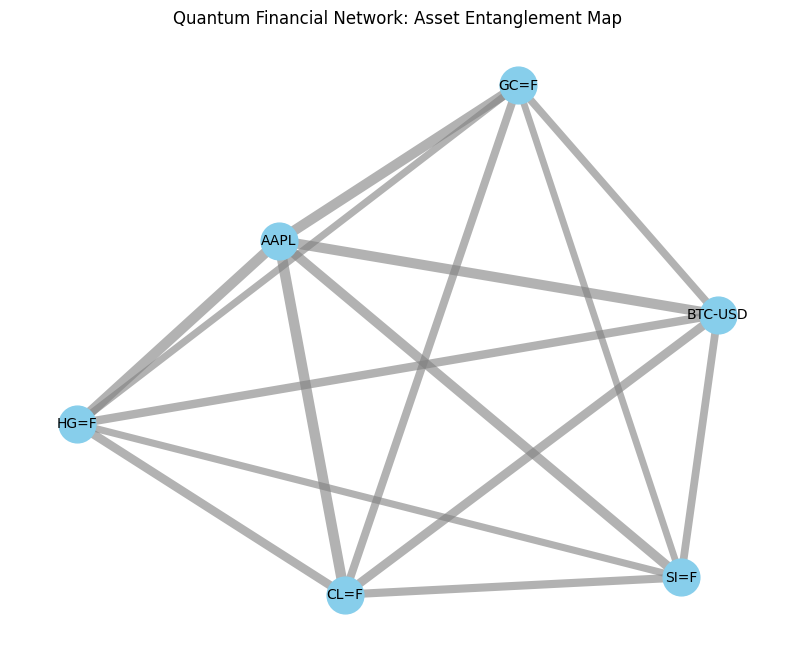

--- Centrality Analysis (Market Leaders) ---
Asset: AAPL     | Centrality: 0.4642
Asset: CL=F     | Centrality: 0.4158
Asset: BTC-USD  | Centrality: 0.4054
Asset: HG=F     | Centrality: 0.3980
Asset: GC=F     | Centrality: 0.3812
Asset: SI=F     | Centrality: 0.3789


In [3]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Analisis Network Theory (Sel 3) ---

# 1. Definisikan daftar aset yang lebih luas
tickers_list = ['GC=F', 'SI=F', 'CL=F', 'HG=F', 'BTC-USD', 'AAPL']
# GC=F (Gold), SI=F (Silver), CL=F (Oil), HG=F (Copper), BTC (Bitcoin), AAPL (Apple)

# Ambil data untuk semua tickers
all_data = yf.download(tickers_list, period="2y")['Close'].pct_change().dropna()

def calculate_qmi_pair(returns, asset_a, asset_b):
    """Fungsi pembantu untuk menghitung QMI antar dua aset"""
    state_a = (returns[asset_a] < 0).astype(int)
    state_b = (returns[asset_b] < 0).astype(int)
    
    # Hitung probabilitas gabungan (Joint Probability Matrix)
    n_ij = np.zeros((2, 2))
    for i in range(len(returns)):
        n_ij[state_a.iloc[i], state_b.iloc[i]] += 1
    
    probs = n_ij / n_ij.sum()
    
    # Matriks Densitas
    rho_ab = probs / np.sum(probs)
    rho_a = np.diag([probs[0,0] + probs[0,1], probs[1,0] + probs[1,1]])
    rho_b = np.diag([probs[0,0] + probs[1,0], probs[0,1] + probs[1,1]])
    
    # Von Neumann Entropy
    def vn_entropy(rho):
        ev = la.eigvalsh(rho)
        ev = ev[ev > 1e-12]
        return -np.sum(ev * np.log2(ev))
    
    return vn_entropy(rho_a) + vn_entropy(rho_b) - vn_entropy(rho_ab)

# 2. Bangun Matriks Adjasensi berdasarkan QMI
G = nx.Graph()

for i, a in enumerate(tickers_list):
    for j, b in enumerate(tickers_list):
        if i < j:
            qmi_val = calculate_qmi_pair(all_data, a, b)
            # Tambahkan edge jika ada keterikatan signifikan
            G.add_edge(a, b, weight=qmi_val)

# 3. Visualisasi Network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42) # Layout agar node tersebar rapi

# Gambar edges dengan ketebalan berdasarkan nilai QMI
weights = [G[u][v]['weight'] * 5 for u, v in G.edges()] # Skalasi untuk visualisasi

nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)
nx.draw_networkx_labels(G, pos, font_size=10, font_family='sans-serif')

plt.title("Quantum Financial Network: Asset Entanglement Map")
plt.axis('off')
plt.show()

# 4. Cari Leader Utama dengan Eigenvector Centrality
centrality = nx.eigenvector_centrality(G, weight='weight')
sorted_centrality = sorted(centrality.items(), key=lambda x: x[1], reverse=True)

print("--- Centrality Analysis (Market Leaders) ---")
for asset, score in sorted_centrality:
    print(f"Asset: {asset:8} | Centrality: {score:.4f}")

1. **Quantum Mutual Information ($I$):** Kita menghitung $I(A:B)$ untuk setiap pasangan unik. Nilai ini merepresentasikan berapa banyak informasi tentang aset $A$ yang terkandung dalam aset $B$ melalui lensa mekanika kuantum.
2. **Topologi Jaringan:** Ketebalan garis (edges) dalam graf menunjukkan kekuatan *entanglement*. Jika garis antara Emas (`GC=F`) dan Perak (`SI=F`) sangat tebal, berarti mereka adalah satu sistem kuantum yang hampir tidak terpisahkan.
3. **Eigenvector Centrality:** Ini adalah cara untuk menemukan "Leader" sejati. Aset dengan skor *centrality* tertinggi bukan hanya aset yang volatil, melainkan aset yang **paling banyak mendikte atau membagikan informasi** ke aset lainnya dalam jaringan tersebut.
4. **Econophysics Insight:** Dalam kondisi krisis, biasanya *Quantum Mutual Information* di seluruh jaringan akan meningkat drastis (fenomena *market coupling*), yang secara visual akan membuat semua node mendekat satu sama lain dalam graf.

In [8]:
# --- Konstruksi Hamiltonian (Sel 4) ---

# 1. Hitung parameter bias (h) dan interaksi (J)
h_L = (pL[0,0] + pL[0,1]) - (pL[1,0] + pL[1,1])
h_F = (pF[0,0] + pF[1,0]) - (pF[0,1] + pF[1,1])
J_LF = qmi  # Menggunakan Quantum Mutual Information sebagai kekuatan interaksi

# 2. Definisikan Operator Pauli-Z dan Identitas
Z = np.array([[1, 0], [0, -1]])
I_mat = np.eye(2)

# 3. Konstruksi Hamiltonian menggunakan Tensor Product (Kronecker)
# H = -hL(Z x I) - hF(I x Z) - J(Z x Z)
H = -h_L * np.kron(Z, I_mat) - h_F * np.kron(I_mat, Z) - J_LF * np.kron(Z, Z)

print("--- Matriks Hamiltonian Sistem (4x4) ---")
print(H)

# 4. Mencari Ground State (Energi Terendah)
eigenvalues, eigenvectors = la.eigh(H)
ground_state_energy = eigenvalues[0]
ground_state_vector = eigenvectors[:, 0]

print(f"\nEnergi Ground State: {ground_state_energy:.4f}")
print(f"Vektor Keadaan Paling Stabil: {ground_state_vector}")

--- Matriks Hamiltonian Sistem (4x4) ---
[[-1.05956817 -0.         -0.         -0.        ]
 [-0.          0.99968494 -0.          0.        ]
 [-0.         -0.          0.9450936   0.        ]
 [-0.          0.          0.         -0.88521038]]

Energi Ground State: -1.0596
Vektor Keadaan Paling Stabil: [1. 0. 0. 0.]
